In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = loadmat('Xtrain.mat')

In [3]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res


In [4]:
def recursive_predict(model, start_window, steps=200):
    model.eval() # set model to evaluation mode
    
    window = start_window.clone().detach() # make sure not to change orginal input
    preds = [] # predictions

    for _ in range(steps):
        with torch.no_grad():
            # LSTM expects input shape (batch_size, seq_len, features)
            pred = model(window.unsqueeze(0)) # Adds dimension to (seq_len, 1) to get correct shape: (1, seq_len, 1)
        
        preds.append(pred.item())

        # shift window
        window = torch.cat([window[1:], pred], dim=0) # removes oldest value and adds new prediction at the end

    return preds

In [5]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()

        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid() # since we normalized the data to [0,1]
        )

    def forward(self, x):
        x = self.flatten(x)
        out = self.linear_relu_stack(x)

        return out

In [6]:
results = []

# how many times to repeat each config
n_runs = 5


# hyperparameters to try
window_sizes = [16,24,32]
output_sizes = [1] # only 1-step prediction for now
hidden_sizes = [32,64]
epochs_list = [500,1000,2000]
learning_rates = [1e-4, 5e-4, 1e-3]

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values


# try all combinations of hyperparameters
for window_size, output_size, hidden_size, epochs, learning_rate in itertools.product(window_sizes, output_sizes, hidden_sizes, epochs_list, learning_rates):

    print(f"\nRunning: window={window_size}, output={output_size}, hidden={hidden_size}, epochs={epochs}, learning rate={learning_rate}")

    # store results across runs
    mae_1_list, mae_200_list = [], []
    mse_1_list, mse_200_list = [], []

    for run in range(n_runs): # repeat training multiple times to average evaluation
        print(f"  Run {run+1}/{n_runs}")

        # recreate dataset with current chosen window
        df = pd.Series(data['Xtrain'].flatten())
        df = data_cleaning(df)

        X, Y = zip(*slices(df, window_size))

        X = np.array(X).reshape(-1, window_size, 1)
        Y = np.array(Y).reshape(-1, output_size)

        split = int(0.8 * len(X))

        X_train, X_val = X[:split], X[split:]
        Y_train, Y_val = Y[:split], Y[split:]

        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train, dtype=torch.float32)
        Y_train = torch.tensor(Y_train, dtype=torch.float32)
        X_val = torch.tensor(X_val, dtype=torch.float32)
        Y_val = torch.tensor(Y_val, dtype=torch.float32)

        # create model
        model = BaselineNN(input_size=window_size, hidden_size=hidden_size, output_size=output_size)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


        #-------------------------------------------------
        # training
        #-------------------------------------------------
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            pred = model(X_train)
            loss = criterion(pred, Y_train)
            loss.backward() # backpropagation
            optimizer.step() # update parameters
        #-------------------------------------------------


        #-------------------------------------------------
        # 1-step evaluation
        #-------------------------------------------------
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val).numpy()
            y_true = Y_val.numpy()

        mae_1 = mean_absolute_error(y_true, val_pred)
        mse_1 = mean_squared_error(y_true, val_pred)
        #-------------------------------------------------


        #-------------------------------------------------
        # 200-step evaluation
        #-------------------------------------------------
        start_idx = split
        start_window = series_full[start_idx:start_idx+window_size]

        # determine max possible steps
        max_steps = len(series_full) - (start_idx + window_size)
        steps = min(200, max_steps)

        true_future = series_full[start_idx+window_size:start_idx+window_size+steps] # true values

        # convert start window to tensor
        start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

        preds = recursive_predict(model, start_tensor, steps) # predictions

        mae_200 = mean_absolute_error(true_future, preds)
        mse_200 = mean_squared_error(true_future, preds)
        #-------------------------------------------------

        # store per run results
        mae_1_list.append(mae_1)
        mae_200_list.append(mae_200)
        mse_1_list.append(mse_1)
        mse_200_list.append(mse_200)


    #-------------------------------------------------
    # store results
    #-------------------------------------------------
    results.append({
        "window": window_size,
        "hidden": hidden_size,
        "epochs": epochs,
        "learning_rate" : learning_rate,

        "mae_1_mean": np.mean(mae_1_list),
        "mae_1_std": np.std(mae_1_list),

        "mae_200_mean": np.mean(mae_200_list),
        "mae_200_std": np.std(mae_200_list),

        "mse_1_mean": np.mean(mse_1_list),
        "mse_200_mean": np.mean(mse_200_list)
    })
    #-------------------------------------------------


    print(f"Avg 1-step MAE: {np.mean(mae_1_list):.4f} +- {np.std(mae_1_list):.4f}")
    print(f"Avg {steps}-step MAE: {np.mean(mae_200_list):.4f} +- {np.std(mae_200_list):.4f}")

#-------------------------------------------------
# sort best models
results_sorted = sorted(results, key=lambda x: x["mae_200_mean"] + x["mae_200_std"])

print("\nTop 5 models (based on mean 200-step MAE):")
for r in results_sorted[:5]:
    print(r)


Running: window=16, output=1, hidden=32, epochs=500, learning rate=0.0001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.1853 +- 0.0111
Avg 197-step MAE: 0.1731 +- 0.0063

Running: window=16, output=1, hidden=32, epochs=500, learning rate=0.0005
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0564 +- 0.0029
Avg 197-step MAE: 0.1500 +- 0.0003

Running: window=16, output=1, hidden=32, epochs=500, learning rate=0.001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0314 +- 0.0018
Avg 197-step MAE: 0.1990 +- 0.0280

Running: window=16, output=1, hidden=32, epochs=1000, learning rate=0.0001
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.1105 +- 0.0113
Avg 197-step MAE: 0.1512 +- 0.0013

Running: window=16, output=1, hidden=32, epochs=1000, learning rate=0.0005
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Avg 1-step MAE: 0.0335 +- 0.0036
Avg 197-step MAE: 0.1819 +- 0.0205

Running: window=16, output=1, hid


194-step MAE: 0.0473

194-step MSE: 0.0043


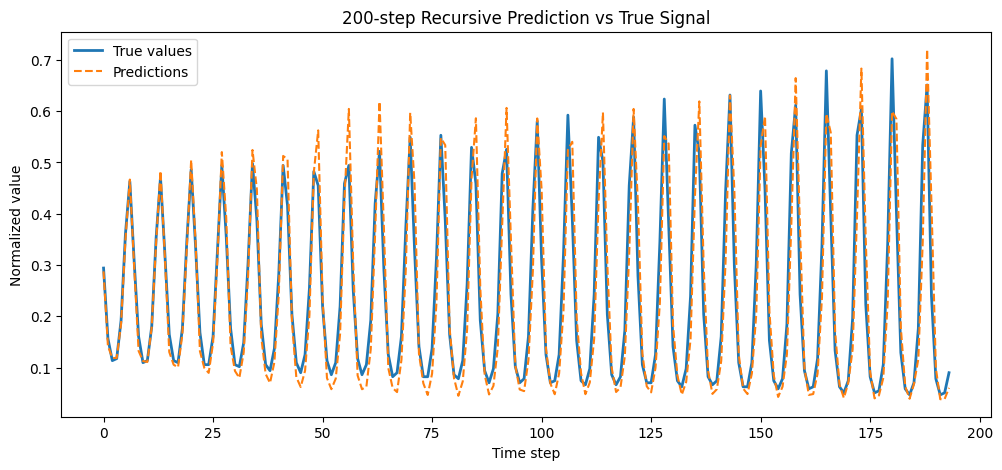

In [9]:
# hyperparameters
window_size = 32
output_size = 1
hidden_size = 64
epochs = 1000
learning_rate = 1e-3
#---------------------------------------------------

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# recreate dataset with current chosen window
df = pd.Series(data['Xtrain'].flatten())
df = data_cleaning(df)

X, Y = zip(*slices(df, window_size))

X = np.array(X).reshape(-1, window_size, 1)
Y = np.array(Y).reshape(-1, 1)

split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
Y_train, Y_val = Y[:split], Y[split:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
Y_val = torch.tensor(Y_val, dtype=torch.float32)

# create model
model = BaselineNN(input_size=window_size, hidden_size=hidden_size, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


#-------------------------------------------------
# training
#-------------------------------------------------
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, Y_train)
    loss.backward() # backpropagation
    optimizer.step() # update parameters
#-------------------------------------------------


#-------------------------------------------------
# 200-step evaluation
#-------------------------------------------------
start_idx = split
start_window = series_full[start_idx:start_idx+window_size]

# determine max possible steps
max_steps = len(series_full) - (start_idx + window_size)
steps = min(200, max_steps)

true_future = series_full[start_idx+window_size:start_idx+window_size+steps] # true values

# convert start window to tensor
start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

preds = recursive_predict(model, start_tensor, steps) # predictions

mae_200 = mean_absolute_error(true_future, preds)
mse_200 = mean_squared_error(true_future, preds)

print(f"\n{steps}-step MAE: {mae_200:.4f}")
print(f"\n{steps}-step MSE: {mse_200:.4f}")

#-----------------------
# plot
#-----------------------
import matplotlib.pyplot as plt

# Create x-axis (time steps)
t = range(len(true_future))

plt.figure(figsize=(12, 5))

# True signal
plt.plot(t, true_future, label="True values", linewidth=2)

# Predicted signal
plt.plot(t, preds, label="Predictions", linestyle='--')

plt.title("200-step Recursive Prediction vs True Signal")
plt.xlabel("Time step")
plt.ylabel("Normalized value")
plt.legend()

plt.show()
